In [ ]:
# --- Imports ---
import os
import zipfile
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import csv
import numpy as np
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0


In [ ]:
# --- Constants ---
NUM_DRONES = 10
NUM_ROUNDS = 10
LOCAL_EPOCHS = 5
BATCH_SIZE = 32
BANDWIDTH_MBPS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(42)
torch.manual_seed(42)


In [ ]:
# --- Step 1: Dataset Setup ---
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
kaggle_json_path = os.path.join(os.getcwd(), 'kaggle.json')
if os.path.exists(kaggle_json_path):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    import shutil
    shutil.copy(kaggle_json_path, os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
else:
    raise FileNotFoundError("Please place your kaggle.json file in the current directory.")

!kaggle datasets download -d yangpeng1995/rsscn7 -p ./data
with zipfile.ZipFile("./data/rsscn7.zip", 'r') as zip_ref:
    zip_ref.extractall("./data/rsscn7")

dataset_path = "./data/rsscn7/RSSCN7-master"

Dataset URL: https://www.kaggle.com/datasets/yangpeng1995/rsscn7
License(s): unknown
rsscn7.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# --- Transform and Load ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

# Balanced Train-Test Split
test_size = 500
train_size = len(full_dataset) - test_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Drone-wise splits
train_indices = list(range(len(train_dataset)))
random.shuffle(train_indices)
split_size = len(train_indices) // NUM_DRONES
splits = [train_indices[i*split_size:(i+1)*split_size] for i in range(NUM_DRONES)]

# Test loader
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
# --- Step 3: Model Definition ---
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def create_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    for param in model.features.parameters():
        param.requires_grad = True  # Fine-tune all layers
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)  # RSSCN7 has 7 classes
    return model.to(DEVICE)


In [ ]:
# Router and VM classes
class Router:
    def __init__(self, threshold=0.10):
        self.threshold = threshold

    def inspect(self, image_tensor):
        return "yes" if image_tensor.mean().item() > self.threshold else "no"

class VM:
    def __init__(self):
        self.model = create_model()

    def process(self, image, label):
        self.model.eval()
        with torch.no_grad():
            image = image.unsqueeze(0).to(DEVICE)
            output = self.model(image)
            _, pred = torch.max(output, 1)
        return pred.item(), label


In [ ]:
# Drone Class
class Drone:
    def __init__(self, drone_id, indices):
        self.id = drone_id
        self.dataset = Subset(full_dataset, indices)
        self.loader = DataLoader(self.dataset, batch_size=BATCH_SIZE, shuffle=True)
        self.model = create_model()
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.images_used = 0
        print(f"Drone {drone_id+1} initialized with Image Tracking.")

    def local_train(self, epochs):
        router = Router()
        vm = VM()
        self.model.train()
        total_loss, steps = 0, 0
        used_images = 0

        for _ in range(epochs):
            for data, targets in self.loader:
                for i in range(len(data)):
                    image = data[i]
                    label = targets[i]
                    if router.inspect(image) == "yes":
                        pred, lbl = vm.process(image, label)
                        image = image.unsqueeze(0).to(DEVICE)
                        label = torch.tensor([label]).to(DEVICE)
                        self.optimizer.zero_grad()
                        output = self.model(image)
                        loss = self.criterion(output, label)
                        loss.backward()
                        self.optimizer.step()
                        total_loss += loss.item()
                        steps += 1
                        used_images += 1

        self.images_used = used_images
        return total_loss / steps if steps else 0

    def get_state(self):
        return {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

    def set_state(self, state):
        self.model.load_state_dict(state)

    def evaluate(self):
        self.model.eval()
        correct = total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(DEVICE), targets.to(DEVICE)
                outputs = self.model(data)
                _, pred = torch.max(outputs, 1)
                correct += (pred == targets).sum().item()
                total += targets.size(0)
        return 100.0 * correct / total

In [ ]:
# --- Step 5: Cloud and FedAvg ---

class Cloud:
    def __init__(self):
        self.model_state = None

    def receive_model(self, state):
        size_mb = sum(param.numel() * 4 for param in state.values()) / 1e6
        transmission_time = size_mb / BANDWIDTH_MBPS  # in seconds
        noise = np.random.normal(1.0, 0.05)
        latency = transmission_time * noise
        print(f" Cloud: Receiving aggregated model ({size_mb:.2f} MB, {latency*1000:.2f} ms latency)")
        time.sleep(latency)
        self.model_state = state.copy()
        return latency  # return transmission delay

    def distribute_model(self):
        return self.model_state.copy()

    def set_model(self, state):
        self.model_state = state.copy()

def fedavg(states):
    new_state = {}
    for k in states[0]:
        new_state[k] = sum(state[k] for state in states) / len(states)
    return new_state


In [ ]:
# --- Step 5: FogBroker Class with Queues, Fitness Tracking, and Acceptance Stats ---
class FogBroker:
    def __init__(self, threshold_mb=16.5):
        self.threshold_mb = threshold_mb
        self.accepted_rounds = []
        self.total_models = []
        self.fitness_scores = []

    def filter_models(self, drone_states, drone_ids, drone_delays, drone_accuracies):
        valid, reprocess, drop = [], [], []
        valid_ids, reprocess_ids, drop_ids = [], [], []
        fitness_scores = []

        max_delay = max(drone_delays) if max(drone_delays) > 0 else 1.0  # avoid divide by zero

        print("\n FogBroker Filtering:")
        for i, (state, delay, acc) in enumerate(zip(drone_states, drone_delays, drone_accuracies)):
            drone_id = drone_ids[i]
            size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6 * np.random.uniform(0.95, 1.05)

            if size_mb <= self.threshold_mb:
                valid.append({
                    "drone_id": drone_id,
                    "state": state,
                    "accuracy": acc,
                    "total_delay": delay
                })
                valid_ids.append(drone_id)

                # Compute fitness for tracking (minimization)
                fitness = alpha * (1 - acc) + beta * (delay / max_delay)
                fitness_scores.append(fitness)

                print(f" Drone {drone_id+1} →  VALID | Size: {size_mb:.2f} MB | Acc: {acc:.2f}% | Delay: {delay*1000:.2f} ms")
            elif size_mb <= self.threshold_mb * 1.2:
                reprocess.append(state)
                reprocess_ids.append(drone_id)
                print(f" Drone {drone_id+1} → REPROCESS | Size: {size_mb:.2f} MB")
            else:
                drop.append(state)
                drop_ids.append(drone_id)
                print(f" Drone {drone_id+1} →  DROPPED | Size: {size_mb:.2f} MB")

        # Track metrics
        self.accepted_rounds.append(len(valid))
        self.total_models.append(len(drone_states))
        self.fitness_scores.append(np.mean(fitness_scores) if fitness_scores else 0)

        return valid, reprocess, drop, valid_ids, reprocess_ids, fitness_scores


In [ ]:
def gwo_select_models(valid_info, alpha=1.0, beta=0.05, num_select=3):
    num_agents = len(valid_info)
    if num_agents <= num_select:
        return valid_info

    max_delay = max([info['total_delay'] for info in valid_info])
    fitness = lambda acc, delay: alpha * (1 - acc / 100.0) + beta * (delay / max_delay)

    sorted_info = sorted(valid_info, key=lambda x: fitness(x["accuracy"], x["total_delay"]))
    return sorted_info[:num_select]


In [ ]:
# --- Step 6: Federated Training with Fog Brokers and GWO ---
# --- System Cost Coefficients (realistic approximations) ---
CPU_RATE = 0.5     # Cost per second of CPU usage
MEMORY_RATE = 0.1  # Cost per MB of memory usage
BANDWIDTH_RATE = 0.05  # Cost per MB of bandwidth used

drones = [Drone(i, splits[i]) for i in range(NUM_DRONES)]
cloud = Cloud()
logs = []
global_accs = []

routerA_ids = list(range(5))
routerB_ids = list(range(5, 10))

alpha = 1.0
beta = 0.05

for rnd in range(1, NUM_ROUNDS + 1):
    print(f"\n================ Round {rnd} ================\n")
    local_states = [None] * NUM_DRONES
    losses = [None] * NUM_DRONES
    model_infos = [None] * NUM_DRONES
    round_latency = 0.0

    for i, drone in enumerate(drones):
        print(f"Drone {i+1} training...")
        loss = drone.local_train(LOCAL_EPOCHS)
        state = drone.get_state()
        accuracy = drone.evaluate()

        exec_time = np.random.uniform(0.15, 0.25)
        size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6 * np.random.uniform(0.95, 1.05)
        trans_time = (size_mb / BANDWIDTH_MBPS) * np.random.normal(1.0, 0.05)
        total_delay = exec_time + trans_time
        round_latency += total_delay

        local_states[i] = state
        losses[i] = loss
        cost = (CPU_RATE * exec_time) + (MEMORY_RATE * size_mb) + (BANDWIDTH_RATE * size_mb)
        model_infos[i] = {
            "state": state,
            "accuracy": accuracy / 100,
            "total_delay": total_delay,
            "drone_id": i,
            "exec_time": exec_time,
            "model_size_mb": size_mb,
            "cost": cost
        }

        print(f"  Loss: {loss:.4f}, Acc: {accuracy:.2f}%, Delay: {total_delay*1000:.2f} ms")

    # --- Fog Filtering ---
    fogA = FogBroker()
    fogB = FogBroker()

    valid_A, _, _, valid_ids_A, _, _ = fogA.filter_models(
        [local_states[i] for i in routerA_ids],
        routerA_ids,
        [model_infos[i]["total_delay"] for i in routerA_ids],
        [model_infos[i]["accuracy"] for i in routerA_ids]
    )
    valid_B, _, _, valid_ids_B, _, _ = fogB.filter_models(
        [local_states[i] for i in routerB_ids],
        routerB_ids,
        [model_infos[i]["total_delay"] for i in routerB_ids],
        [model_infos[i]["accuracy"] for i in routerB_ids]
    )

    model_infos_A = [model_infos[i] for i in valid_ids_A]
    model_infos_B = [model_infos[i] for i in valid_ids_B]

    # --- GWO Model Selection ---
    print("\n GWO Selecting Top 3 Models from Router A")
    top_A = gwo_select_models(model_infos_A, alpha, beta)
    print(" Selected drones from Router A:", [info['drone_id'] + 1 for info in top_A])
    agg_A = fedavg([info["state"] for info in top_A]) if top_A else None

    print("\n GWO Selecting Top 3 Models from Router B")
    top_B = gwo_select_models(model_infos_B, alpha, beta)
    print(" Selected drones from Router B:", [info['drone_id'] + 1 for info in top_B])
    agg_B = fedavg([info["state"] for info in top_B]) if top_B else None

    # --- Cloud Aggregation ---
    if agg_A and agg_B:
        print("\n  Cloud Aggregating filtered updates...")
        agg_cloud = fedavg([agg_A, agg_B])
        cloud_latency = cloud.receive_model(agg_cloud)
        round_latency += cloud_latency

        cloud.set_model(agg_cloud)
        updated_state = cloud.distribute_model()
        for drone in drones:
            drone.set_state(updated_state)

        # Evaluate the global model (after aggregation)
        temp_model = create_model()
        temp_model.load_state_dict(updated_state)
        temp_model.to(DEVICE)
        temp_model.eval()

        correct = 0
        total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(DEVICE), targets.to(DEVICE)
                outputs = temp_model(data)
                _, pred = torch.max(outputs, 1)
                correct += (pred == targets).sum().item()
                total += targets.size(0)

        acc = 100.0 * correct / total
        global_accs.append(acc)
        print(f" Aggregated Global Model Accuracy: {acc:.2f}%")

        avg_cost = np.mean([info["cost"] for info in model_infos if info is not None])

        # --- Acceptance Rate and Fitness ---
        acceptance_rate_A = len(model_infos_A) / len(routerA_ids)
        acceptance_rate_B = len(model_infos_B) / len(routerB_ids)

        avg_fitness_A = 0
        avg_fitness_B = 0

        if model_infos_A:
            max_delay_A = max(info['total_delay'] for info in model_infos_A)
            avg_fitness_A = np.mean([
                alpha * (1 - info['accuracy']) + beta * (info['total_delay'] / max_delay_A)
                for info in model_infos_A
            ])

        if model_infos_B:
            max_delay_B = max(info['total_delay'] for info in model_infos_B)
            avg_fitness_B = np.mean([
                alpha * (1 - info['accuracy']) + beta * (info['total_delay'] / max_delay_B)
                for info in model_infos_B
            ])


        # --- Logging Everything ---
        acceptance_rate_A = fogA.accepted_rounds[-1] / fogA.total_models[-1] if fogA.total_models[-1] > 0 else 0
        acceptance_rate_B = fogB.accepted_rounds[-1] / fogB.total_models[-1] if fogB.total_models[-1] > 0 else 0

        avg_fitness_A = fogA.fitness_scores[-1] if fogA.fitness_scores else 0
        avg_fitness_B = fogB.fitness_scores[-1] if fogB.fitness_scores else 0

        logs.append([
            rnd, acc, round_latency * 1000, cloud_latency * 1000, avg_cost,
            acceptance_rate_A, acceptance_rate_B,
            avg_fitness_A, avg_fitness_B
        ] + losses)

    else:
        print(" Aggregation failed due to no valid models.")


Drone 1 initialized with Image Tracking.
Drone 2 initialized with Image Tracking.
Drone 3 initialized with Image Tracking.
Drone 4 initialized with Image Tracking.
Drone 5 initialized with Image Tracking.
Drone 6 initialized with Image Tracking.
Drone 7 initialized with Image Tracking.
Drone 8 initialized with Image Tracking.
Drone 9 initialized with Image Tracking.
Drone 10 initialized with Image Tracking.

================ Round 1 ================

Drone 1 training...
  Loss: 0.9877, Acc: 19.80%, Delay: 502.66 ms
Drone 2 training...
  Loss: 1.0007, Acc: 10.00%, Delay: 536.95 ms
Drone 3 training...
  Loss: 0.7666, Acc: 9.60%, Delay: 494.86 ms
Drone 4 training...
  Loss: 1.0829, Acc: 21.00%, Delay: 551.05 ms
Drone 5 training...
  Loss: 1.0215, Acc: 21.20%, Delay: 564.69 ms
Drone 6 training...
  Loss: 1.0840, Acc: 18.60%, Delay: 513.63 ms
Drone 7 training...
  Loss: 0.8038, Acc: 14.00%, Delay: 560.64 ms
Drone 8 training...
  Loss: 1.0722, Acc: 7.60%, Delay: 488.12 ms
Drone 9 training...

In [ ]:
# --- Step 7: Save Logs (CSV) ---

csv_path = "./gwo_federated_logs.csv"

with open(csv_path, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
    "Round", "Global Accuracy (%)", "Total Latency (ms)", "Cloud Latency (ms)","Average Cost", "Acceptance Rate A", "Acceptance Rate B",
    "Avg Fitness A", "Avg Fitness B"] + [f"Drone {i+1} Loss" for i in range(NUM_DRONES)])

    writer.writerows(logs)

print(f"\n Logs saved to: {csv_path}")



 Logs saved to: ./gwo_federated_logs.csv


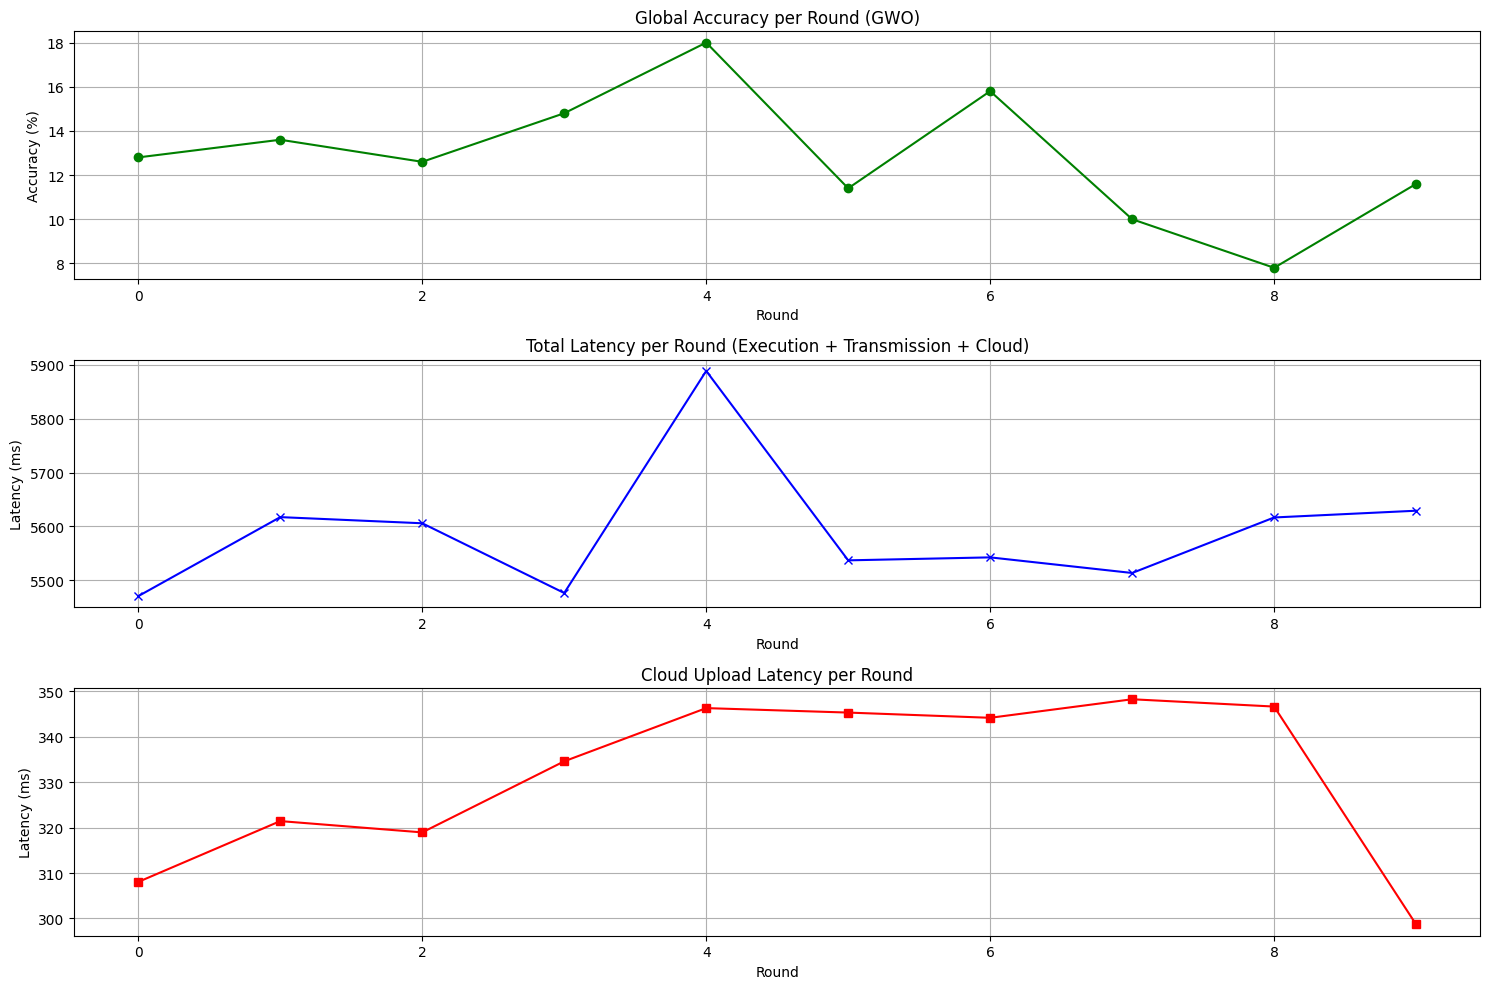

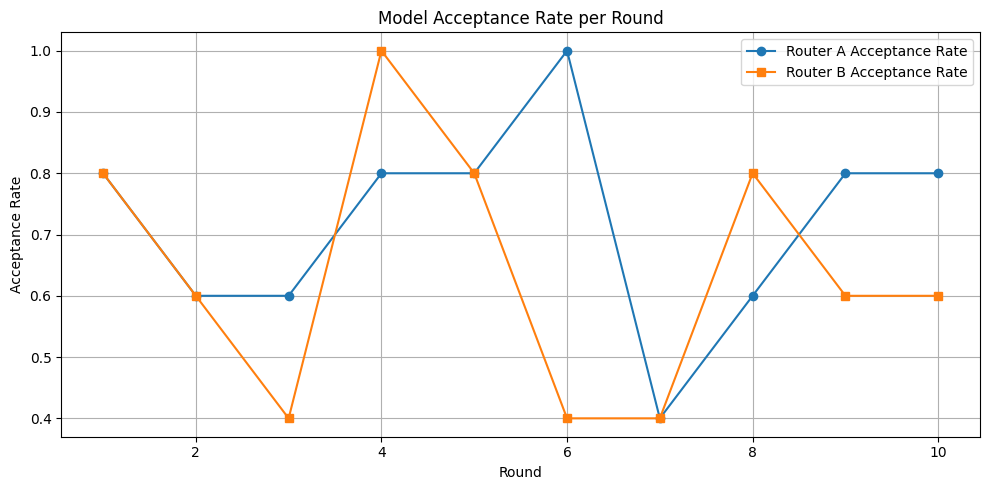

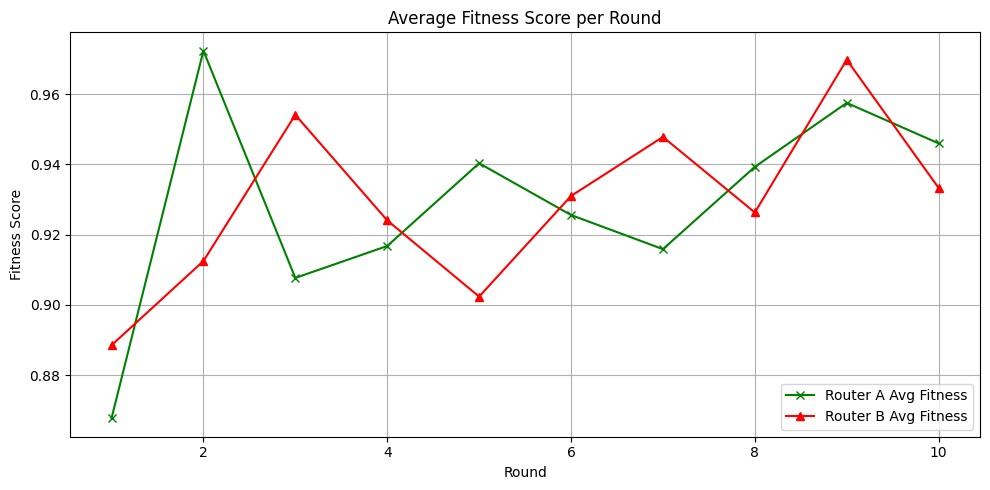

In [ ]:
# --- Step 8: Plot Metrics ---

plt.figure(figsize=(15, 10))

# Plot Accuracy
plt.subplot(3, 1, 1)
plt.plot(global_accs, marker='o', color='green')
plt.title("Global Accuracy per Round (GWO)")
plt.xlabel("Round")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# Plot Total Latency
total_latency_ms = [row[2] for row in logs]
plt.subplot(3, 1, 2)
plt.plot(total_latency_ms, marker='x', color='blue')
plt.title("Total Latency per Round (Execution + Transmission + Cloud)")
plt.xlabel("Round")
plt.ylabel("Latency (ms)")
plt.grid(True)

# Plot Cloud Latency
cloud_latency_ms = [row[3] for row in logs]
plt.subplot(3, 1, 3)
plt.plot(cloud_latency_ms, marker='s', color='red')
plt.title("Cloud Upload Latency per Round")
plt.xlabel("Round")
plt.ylabel("Latency (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()


acceptance_A = [a / t if t > 0 else 0 for a, t in zip(fogA.accepted_rounds, fogA.total_models)]
acceptance_B = [a / t if t > 0 else 0 for a, t in zip(fogB.accepted_rounds, fogB.total_models)]

fitness_A = fogA.fitness_scores
fitness_B = fogB.fitness_scores

rounds = list(range(1, NUM_ROUNDS + 1))

# Extract from logs (indexes 5 to 8)
acceptance_A = [row[5] for row in logs]
acceptance_B = [row[6] for row in logs]
avg_fit_A = [row[7] for row in logs]
avg_fit_B = [row[8] for row in logs]

# Model Acceptance Rate
plt.figure(figsize=(10, 5))
plt.plot(rounds, acceptance_A, label="Router A Acceptance Rate", marker='o')
plt.plot(rounds, acceptance_B, label="Router B Acceptance Rate", marker='s')
plt.title("Model Acceptance Rate per Round")
plt.xlabel("Round")
plt.ylabel("Acceptance Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Average Fitness Score
plt.figure(figsize=(10, 5))
plt.plot(rounds, avg_fit_A, label="Router A Avg Fitness", marker='x', color='green')
plt.plot(rounds, avg_fit_B, label="Router B Avg Fitness", marker='^', color='red')
plt.title("Average Fitness Score per Round")
plt.xlabel("Round")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

